In [75]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

C:\Users\roeth\AppData\Local\Temp\ipykernel_22632\1108342508.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  return y*(1/y-1)
C:\Users\roeth\AppData\Local\Temp\ipykernel_22632\1108342508.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  return y*(1/y-1)


Text(0, 0.5, 'R_k/K²')

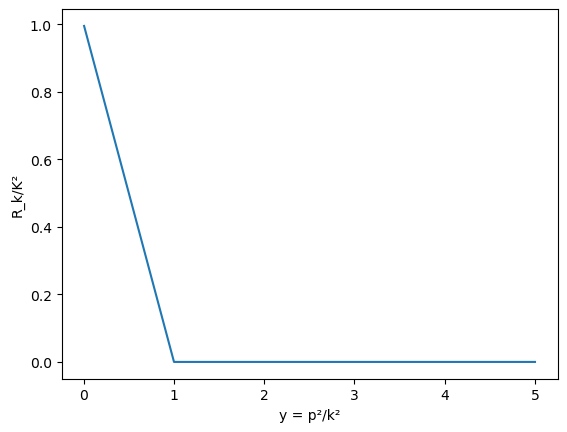

In [76]:
# Litim regulator

def litim(y):
    if 1 < y:
        return 0
    else:
        return y*(1/y-1)
    
y = np.linspace(0,5,1000)
R_vals = np.zeros(1000)

for i in range(len(y)):
    R_vals[i] = litim(y[i])

plt.plot(y, R_vals)
plt.xlabel("y = p²/k²")
plt.ylabel("R_k/K²")

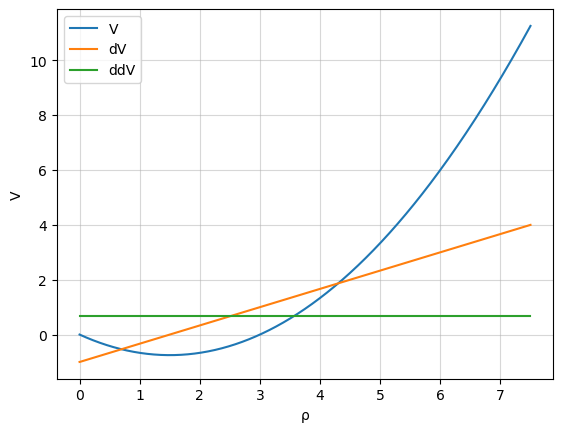

In [77]:
data = np.loadtxt("../results/V_classical.txt", skiprows=1, delimiter=",")
data_1 = np.loadtxt("../results/V_classical_prime.txt", skiprows=1, delimiter=",")
data_2 = np.loadtxt("../results/V_classical_doubleprime.txt", skiprows=1, delimiter=",")

ρ = data[:,0]
V = data[:,1]

ρ2 = data_1[:,0]
dV = data_1[:,1]

ρ3 = data_2[:,0]
ddV = data_2[:,1]

plt.plot(ρ,V,label="V")
plt.xlabel("ρ")
plt.ylabel("V")
plt.plot(ρ2,dV, label="dV")
plt.plot(ρ3,ddV, label="ddV")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

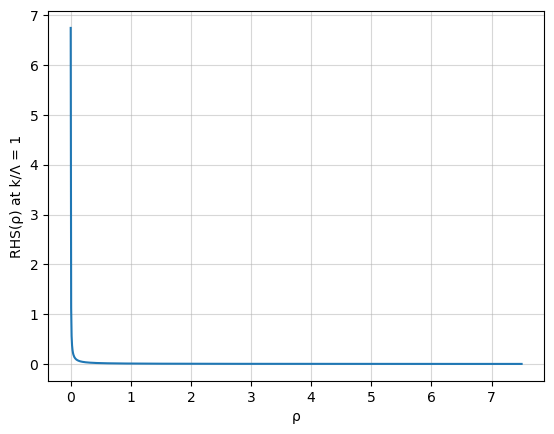

In [78]:
RHS = np.loadtxt("../results/RHS.txt", skiprows=1, delimiter=",")

ρ = RHS[:,0]
RHS = RHS[:,1]

plt.plot(ρ,RHS)
plt.xlabel("ρ")
plt.ylabel("RHS(ρ) at k/Λ = 1")
plt.grid(alpha=0.5)

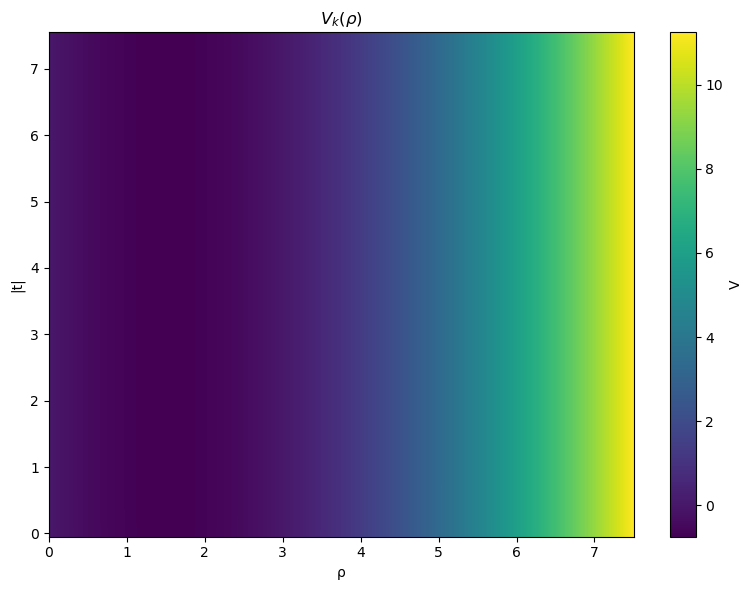

In [79]:
from pathlib import Path

result_dir = Path("../results")

files = sorted(
    [
        p for p in result_dir.glob("V_*.txt")
        if p.name not in {
            "V_classical.txt",
            "V_classical_prime.txt",
            "V_classical_doubleprime.txt",
            "RHS.txt"
        }
    ],
    key=lambda p: float(p.stem.split("_")[1])
)

t_values = []
rho_grid = None
V_grid = []

for path in files:
    data = np.loadtxt(path, skiprows=1, delimiter=",")
    rho = data[:,0]
    V = data[:,1]

    if rho_grid is None:
        rho_grid = rho
    elif not np.allclose(rho_grid, rho):
        raise ValueError(f"rho grid mismatch in {path.name}")

    t_values.append(float(path.stem.split("_")[1]))
    V_grid.append(V)

V_grid = np.array(V_grid)
t_values = np.array(t_values)

plt.figure(figsize=(8,6))
mesh = plt.pcolormesh(rho_grid, t_values, V_grid, shading="auto", cmap="viridis")
plt.xlabel("ρ")
plt.ylabel("|t|")
plt.title(rf"$V_k(ρ)$")
plt.colorbar(mesh, label="V")
plt.tight_layout()

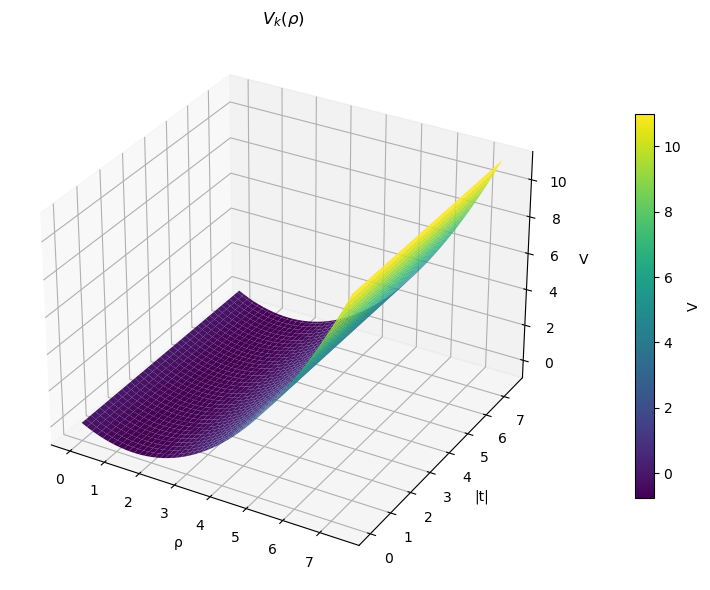

In [80]:
Rho, T = np.meshgrid(rho_grid, t_values)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(Rho, T, V_grid, cmap="viridis", edgecolor="none")
ax.set_xlabel("ρ")
ax.set_ylabel("|t|")
ax.set_zlabel("V")
ax.set_title(r"$V_k(\rho)$")
fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label="V")

plt.tight_layout()
plt.show()

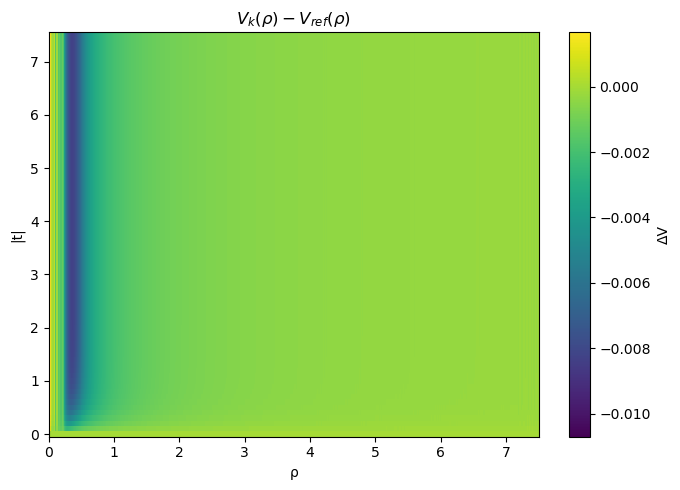

In [81]:
# Get V_ref (V at t=0, which is the first row)
V_ref = V_grid[0]

# Calculate the difference
V_diff = V_grid - V_ref

# Plot the difference
plt.figure(figsize=(7,5))
mesh = plt.pcolormesh(rho_grid, t_values, V_diff, shading="auto", cmap="viridis")
plt.xlabel("ρ")
plt.ylabel("|t|")
plt.title(r"$V_k(\rho) - V_{ref}(\rho)$")
plt.colorbar(mesh, label="ΔV")
plt.tight_layout()

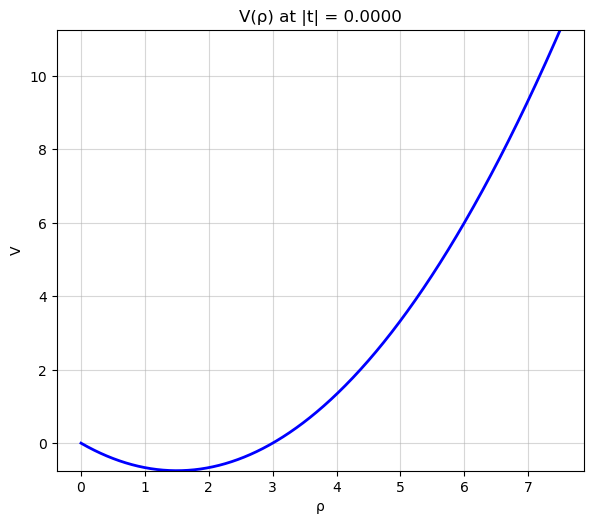

In [82]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 5))

def animate(frame):
    ax.clear()
    ax.plot(rho_grid, V_grid[frame], 'b-', linewidth=2)
    ax.set_xlabel("ρ")
    ax.set_ylabel("V")
    ax.set_title(f"V(ρ) at |t| = {t_values[frame]:.4f}")
    ax.grid(alpha=0.5)
    ax.set_ylim(V_grid.min(), V_grid.max())

anim = FuncAnimation(fig, animate, frames=len(t_values), interval=100, repeat=True)
plt.tight_layout()
HTML(anim.to_jshtml())